In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, rv_continuous, mannwhitneyu

In [7]:
PDF_X = np.linspace(-100, 100, 1000)
trapezoid = np.trapz

In [8]:
class AsymmetricGaussian(rv_continuous):
    """
    Custom Asymmetric Gaussian distribution.
    Use loc for the mean, and unc_minus/unc_plus as shape parameters.
    """
    def _pdf(self, x, unc_minus, unc_plus):
        """x is already shifted by loc internally by scipy"""
        pdf = np.where(
            x < 0,
            np.exp(-0.5 * (x / unc_minus)**2),
            np.exp(-0.5 * (x / unc_plus)**2)
        )
        
        norm = np.sqrt(2 / (np.pi * (unc_plus + unc_minus)**2))
        return norm * pdf

    def _rvs(self, unc_minus, unc_plus, size=None, random_state=None):
        """Generate random samples from the asymmetric Gaussian"""
        rng = np.random.default_rng()
        # To match _pdf, each side must carry mass unc/(unc_minus + unc_plus),
        # not 50/50: pick the side first, then draw a half-normal on that side
        left = rng.random(size) < unc_minus / (unc_minus + unc_plus)
        half = np.abs(rng.standard_normal(size))
        samples = np.where(left, -half * unc_minus, half * unc_plus)
        return samples

ag = AsymmetricGaussian()

In [ ]:
base_std = 5
base_pdf = ag.pdf(PDF_X, loc=0, unc_minus=base_std, unc_plus=base_std)

test_pdfs = dict(
    base_pdf = dict(loc=0,unc_minus=5, unc_plus=5),
    deltafunc_pdf = dict(loc=0, unc_minus=1, unc_plus=1),
    deltafunc_slightly_offset_pdf = dict(loc=5, unc_minus=1, unc_plus=1),
    deltafunc_offset_pdf = dict(loc=50, unc_minus=1, unc_plus=1),
    wide_pdf = dict(loc=0,unc_minus=10, unc_plus=10),
    wide_slightly_offset_pdf = dict(loc=5, unc_minus=10, unc_plus=10),
    wide_pdf_offset = dict(loc=15, unc_minus=10, unc_plus=10),
    wide_pdf_veryoffset = dict(loc=50,unc_minus=10, unc_plus=10),
    verywide_pdf = dict(loc=0,unc_minus=50, unc_plus=50),
    verywide_slightly_offset_pdf = dict(loc=5,unc_minus=50, unc_plus=50),
    verywide_pdf_offset = dict(loc=50,unc_minus=50, unc_plus=50),
    asymmetric_pdf_deltafunc = dict(loc=0, unc_minus=0.5, unc_plus=1),
    asymmetric_pdf_deltafunc_offset = dict(loc=50, unc_minus=0.5, unc_plus=1),
    asymmetric_pdf_wide = dict(loc=0, unc_minus=7.5, unc_plus=12.5),
    asymmetric_pdf_wide_offset = dict(loc=50, unc_minus=7.5, unc_plus=12.5),
    asymmetric_pdf_wide_offset_neg = dict(loc=-50, unc_minus=7.5, unc_plus=12.5),
    asymmetric_pdf_very_skewed = dict(loc=0, unc_minus=50, unc_plus=1),
    asymmetric_pdf_very_skewed_offset = dict(loc=20, unc_minus=50, unc_plus=1),
    asymmetric_pdf_very_skewed_very_offset_pos = dict(loc=80, unc_minus=50, unc_plus=1),
    asymmetric_pdf_very_skewed_very_offset_neg = dict(loc=-80, unc_minus=50, unc_plus=1),
    asymmetric_pdf_very_skewed_slightly_offset_neg = dict(loc=-5, unc_minus=50, unc_plus=1),
    asymmetric_pdf_very_skewed_moderately_offset_neg = dict(loc=-8, unc_minus=50, unc_plus=1),
    # Straddles the GW: mode below (-6) with a narrow lower tail (unc_minus=1)
    # facing the GW and a wide upper tail (unc_plus=15) pointing away. The median
    # lands just above the GW, so v4 scores it on the narrow facing tail ALONE
    # and ignores the large far-side uncertainty; v2 blends both tails in. This
    # is the structure that maximizes the v2-vs-v4 disagreement.
    asymmetric_v4_straddle = dict(loc=-6, unc_minus=1, unc_plus=15),
)

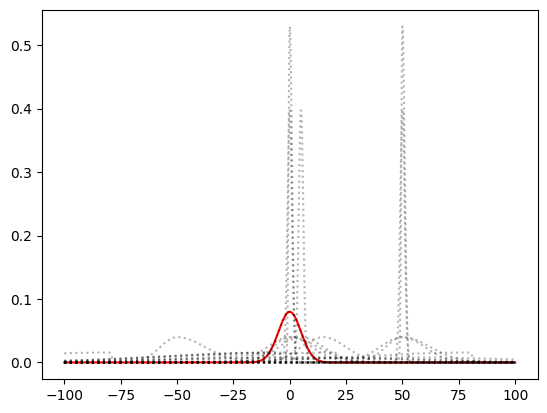

In [10]:
fig, ax = plt.subplots()

ax.plot(PDF_X, base_pdf, color="r")

for label, test_params in test_pdfs.items():
    test = ag.pdf(PDF_X, **test_params)
    ax.plot(PDF_X, test, color="k", alpha=0.3, linestyle=":")

In [20]:
from scipy.special import erfc

# Hybrid Consistent Probability and Z-Score
# In actual code, instead of z_thresh and uncertainty, filter by phot-z and spec-z
def hybrid_cons_prob(mean1, mean2, std1, unc_minus, unc_plus, wt=1, z_thresh=1.1, width_thresh=0.5):
    # Consider using median and MAD instead of mean and std
    mean_diff = mean2 - mean1
    host_scale = np.sqrt(unc_minus**2 + unc_plus**2)
    z_gw = mean_diff / std1

    if np.abs(z_gw) < z_thresh and host_scale < width_thresh * std1:
        # Score depends only on the z-score, rescaled into [0.9, 1.0]
        return 1.0 - 0.1 * (np.abs(z_gw) / z_thresh)

    w_minus = 0.5 * erfc(-z_gw / np.sqrt(2))
    w_plus = 1 - w_minus

    sigma_minus = wt * np.sqrt(2 * (std1**2 + unc_minus**2))
    sigma_plus = wt * np.sqrt(2 * (std1**2 + unc_plus**2))
    score_minus = erfc(np.abs(mean_diff) / sigma_minus)
    score_plus = erfc(np.abs(mean_diff) / sigma_plus)

    return w_minus * score_minus + w_plus * score_plus

In [ ]:
def robust_stats(pdf, x=PDF_X, p_lo=0.1587):
    # 15.87/84.13 reproduces standard 1 sigma for a symmetric gaussian distribution
    cdf = np.cumsum(pdf)
    cdf = cdf / cdf[-1]
    q_lo, q50, q_hi = np.interp([p_lo, 0.5, 1 - p_lo], cdf, x)
    z = norm.ppf(1 - p_lo)
    return q50, (q50 - q_lo) / z, (q_hi - q50) / z


def hybrid_cons_prob_v2(gw_pdf, host_pdf, x=PDF_X, wt=1, z_thresh=1.1, width_thresh=0.5):
    # robust location + scale straight from the distributions
    m1, gm, gp = robust_stats(gw_pdf, x)
    mad1 = 0.5 * (gm + gp)                 # GW is symmetric -> gm == gp == sigma
    m2, s_minus, s_plus = robust_stats(host_pdf, x)

    med_diff = m2 - m1
    host_scale = np.sqrt(s_minus**2 + s_plus**2)
    z_gw = med_diff / mad1

    if np.abs(z_gw) < z_thresh and host_scale < width_thresh * mad1:
        # Score depends only on the (robust) z-score, rescaled into [0.9, 1.0]
        return 1.0 - 0.1 * (np.abs(z_gw) / z_thresh)

    w_minus = 0.5 * erfc(-z_gw / np.sqrt(2))
    w_plus = 1 - w_minus

    sigma_minus = wt * np.sqrt(2 * (mad1**2 + s_minus**2))
    sigma_plus = wt * np.sqrt(2 * (mad1**2 + s_plus**2))

    score_minus = erfc(np.abs(med_diff) / sigma_minus)
    score_plus = erfc(np.abs(med_diff) / sigma_plus)

    return w_minus * score_minus + w_plus * score_plus


def hybrid_cons_prob_v3(gw_pdf, host_pdf, std1, unc_minus, unc_plus, x=PDF_X, wt=1, z_thresh=1.1, width_thresh=0.5):
    # Like v2 (median location, from robust_stats) but the SCALE is the reported
    # std -- std1 and unc_minus/unc_plus -- instead of robust MAD-family widths.
    m1, _, _ = robust_stats(gw_pdf, x)
    m2, _, _ = robust_stats(host_pdf, x)

    med_diff = m2 - m1
    host_scale = np.sqrt(unc_minus**2 + unc_plus**2)
    z_gw = med_diff / std1

    if np.abs(z_gw) < z_thresh and host_scale < width_thresh * std1:
        # Score depends only on the (robust) z-score, rescaled into [0.9, 1.0]
        return 1.0 - 0.1 * (np.abs(z_gw) / z_thresh)

    w_minus = 0.5 * erfc(-z_gw / np.sqrt(2))
    w_plus = 1 - w_minus

    sigma_minus = wt * np.sqrt(2 * (std1**2 + unc_minus**2))
    sigma_plus = wt * np.sqrt(2 * (std1**2 + unc_plus**2))
    score_minus = erfc(np.abs(med_diff) / sigma_minus)
    score_plus = erfc(np.abs(med_diff) / sigma_plus)

    return w_minus * score_minus + w_plus * score_plus


def hybrid_cons_prob_v4(gw_pdf, host_pdf, x=PDF_X, wt=1, z_thresh=1.1, width_thresh=0.5):
    # median location + robust MAD-family widths, but with the ORIGINAL
    # consistency_probability that discretely picks a single tail (no smooth
    # blend between tails like v2).
    m1, gm, gp = robust_stats(gw_pdf, x)
    mad1 = 0.5 * (gm + gp)                 # GW is symmetric -> gm == gp == sigma
    m2, s_minus, s_plus = robust_stats(host_pdf, x)

    med_diff = m2 - m1
    host_scale = np.sqrt(s_minus**2 + s_plus**2)
    z_gw = med_diff / mad1

    if np.abs(z_gw) < z_thresh and host_scale < width_thresh * mad1:
        # Score depends only on the (robust) z-score, rescaled into [0.9, 1.0]
        return 1.0 - 0.1 * (np.abs(z_gw) / z_thresh)

    if m2 < m1:
        # host median below the GW -> the upper tail is the one facing the GW
        mad2 = s_plus
    else:
        mad2 = s_minus

    sigma_diff = wt * np.sqrt(2 * (mad1**2 + mad2**2))

    # abs: med_diff can be negative, erfc of a negative would exceed 1
    score = erfc(np.abs(med_diff) / sigma_diff)
    return score

In [ ]:
for label, test in test_pdfs.items():
    test_pdf = ag.pdf(PDF_X, **test)

    # Normalization
    test_pdf = test_pdf / np.sum(test_pdf)
    base_pdf = base_pdf / np.sum(base_pdf)

    final_score = hybrid_cons_prob(0, test['loc'], base_std, unc_minus=test['unc_minus'], unc_plus=test['unc_plus'])

    fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
    ax.plot(PDF_X, base_pdf, color="r", label="Sample GW PDF", alpha=0.5)
    ax.plot(PDF_X, test_pdf, color="k", label="Sample Host PDF", alpha=0.5)
    ax.legend()
    ax.set_title(f"{label}\nFinal Score: {final_score}", pad=12)
    fig.savefig(f"hybrid_tests/v1/{label}.png", dpi=300, bbox_inches="tight")
    plt.close(fig)

In [ ]:
base_plot = base_pdf / np.sum(base_pdf)

for label, test in test_pdfs.items():
    print(label)
    host_pdf = ag.pdf(PDF_X, **test)
    host_plot = host_pdf / np.sum(host_pdf)

    final_score = hybrid_cons_prob_v2(base_pdf, host_pdf, PDF_X)
    med, _, _ = robust_stats(host_pdf)

    fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
    ax.plot(PDF_X, base_plot, color="r", label="Sample GW PDF", alpha=0.5)
    ax.plot(PDF_X, host_plot, color="k", label="Sample Host PDF", alpha=0.5)
    ax.axvline(med, color="b", ls="--", lw=1, alpha=0.7, label=f"host median={med:.1f}")
    ax.legend(fontsize=8)
    ax.set_title(f"{label}\nv2 (median/MAD, 10/90) Score: {final_score:.4f}", pad=12)
    fig.savefig(f"hybrid_tests/v2/{label}.png", dpi=300, bbox_inches="tight")
    plt.close(fig)

base_pdf
-8.327030426523379e-16
deltafunc_pdf
-5.551353617682252e-17
deltafunc_slightly_offset_pdf
1.0000367458266957
deltafunc_offset_pdf
10.000404494290578
wide_pdf
-4.174617920497054e-15
wide_slightly_offset_pdf
1.0000429014191807
wide_pdf_offset
3.0001287323445593
wide_pdf_veryoffset
10.000428700944504
verywide_pdf
-6.578354036953469e-15
verywide_slightly_offset_pdf
0.8645636682651389
verywide_pdf_offset
8.021937841931493
asymmetric_pdf_deltafunc
0.0639213259310811
asymmetric_pdf_deltafunc_offset
10.064340132096365
asymmetric_pdf_wide
0.6334001169346724
asymmetric_pdf_wide_offset
10.633738614309825
asymmetric_pdf_wide_offset_neg
-9.367036101223148
asymmetric_pdf_very_skewed
-6.240048352228787
asymmetric_pdf_very_skewed_offset
-2.462073052435407
asymmetric_pdf_very_skewed_very_offset_pos
9.414478760885995
asymmetric_pdf_very_skewed_very_offset_neg
-17.84296001588393
asymmetric_pdf_very_skewed_slightly_offset_neg
-7.149850198567534
asymmetric_pdf_very_skewed_moderately_offset_neg
-7.

In [ ]:
import os

os.makedirs("hybrid_tests/v4", exist_ok=True)
base_plot = base_pdf / np.sum(base_pdf)

for label, test in test_pdfs.items():
    host_pdf = ag.pdf(PDF_X, **test)
    host_plot = host_pdf / np.sum(host_pdf)

    final_score = hybrid_cons_prob_v4(base_pdf, host_pdf, x=PDF_X)
    med, _, _ = robust_stats(host_pdf)

    fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
    ax.plot(PDF_X, base_plot, color="r", label="Sample GW PDF", alpha=0.5)
    ax.plot(PDF_X, host_plot, color="k", label="Sample Host PDF", alpha=0.5)
    ax.axvline(med, color="b", ls="--", lw=1, alpha=0.7, label=f"host median={med:.1f}")
    ax.legend(fontsize=8)
    ax.set_title(f"{label}\nv4 (median/MAD, discrete tail) Score: {final_score:.4f}", pad=12)
    fig.savefig(f"hybrid_tests/v4/{label}.png", dpi=300, bbox_inches="tight")
    plt.close(fig)